# Experiment #1:

In this experiment, we will compare the performance of the selected techniques for modeling hierarchical taxonomies from textual data. The goal of this experiment is to find the best performing technique to generated taxonomies for a Knowledge Graph (KG). Therefore the generated triples will be integrated into an existing KG. As baseline model for KG recommender systems we use the current state of the art Graph Neural Network (GNN) model `KGIL`, which the code is available on [GitHub](https://github.com/shuyao-wang/KGIL).

**Data:**
We will use the `Amazon Video Games` dataset. The dataset was published by the McAuley Lab from the University of California, San Diego and contains reviews split into train and test set and metadata of products from Amazon. We will use the latest version of the dataset from 2023. The dataset is for the public available on [HuggingFace]('https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'). We load the 5-core version of the dataset. To shrink the computational and memory footprint further we filter the dataset to a 10-core version.

**Techniques:**
We will compare the following techniques:
- Hierarchical topic modeling. _This technique is called Topic modeling and a common NLP downstream task. The technique extract information from text document and organize them into a broad topics. In this case, we will use `three diferent embedding models`, `kmeans` as clustering algorithm, `hdbscan` as hierarchical clustering algorithm and `tf-idf` for naming the topics._ 
- Named Entity Recognition. _The second model used is `rebel-large` from [HuggingFace]("https://huggingface.co/Babelscape/rebel-large"). This model is a Named Entity Recognition model. The model is able to extract the entities (Named Entities Recognition) and predict the relations between them (Relation Extraction / classification). This task is a common NLP downstream task and focuses on extracting on word or sentence level information._  
- LLMHierarchyCOL. _This technique was developed by the author of this thesis. The technique uses as LLM `gemma3-3b` from Google DeepMind to generate a detailed product description from a short summary. We load locally from [Ollama]("https://ollama.com/library/llama3.2). The assumption behind the summary detalisation is presented in the thesis. The detailed product description is then used to extract Key Words with the Library `KeyBERT` using the SentenceTransformer model `sentence-transformers/paraphrase-mpnet-base-v2` from [HuggingFace](https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2). The extracted keywords will be fed into a LLM using Chain of Layer (COL) to generate, update and review the taxonomy._

Furthermore the techniques extract in different ways on different granularity levels information to organize them.

**Evaluation**:

_Quantitative:_
- Similarities: to observe the differences in the topic clusters between the embedding models we measure the `levenshtein distance` between the topic clusters.
- Performance: To evaluate the performance of the techniques we will use the `KGIL` model as baseline model. We will evaluate the performance of the techniques by measuring the `Precision@20`, `Recall@20`, `NDCG@20` and `Hit Ratio@20`.
- Cost: We measure the time consumption to model the taxonomies and train the KGIL model for each technique and the memory footprint.

_Qualitative:_
- Taxonomy quality: We observe the quality of the generated taxonomies by visualizing them. 
- Error analysis: We conduct an error analysis on the KGIL model for each technique. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.


## 0. Setup

In [137]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 

from time import time # time measurement
import Levenshtein # levenshtein distance


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.data_processing import Build_KG
# load kgil metrics
from models.KGIL.utils.metrics import (
    levenshtein_distance,
    calc_cosine_similarity_fixed
)



In [138]:



embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


# Create a function to safely extract metrics from tables
def safe_extract_metrics(metrics_df, method_name):
    metrics = {}
    metrics['Method'] = method_name
    
    # Check if metrics_df is a PrettyTable
    if hasattr(metrics_df, 'get_string'):
        # Extract data from PrettyTable
        for row in metrics_df._rows:
            if row[0] == 'Recall@20':
                metrics['Recall@20'] = float(row[1])
            elif row[0] == 'Precision@20':
                metrics['Precision@20'] = float(row[1])
            elif row[0] == 'NDCG@20':
                metrics['NDCG@20'] = float(row[1])
            elif row[0] == 'Hit_Ratio@20':
                metrics['Hit_Ratio@20'] = float(row[1])
            elif row[0] == 'AUC':
                metrics['AUC'] = float(row[1])
    else:
        # Assume it's a DataFrame
        try:
            metrics['Recall@20'] = metrics_df.loc[metrics_df.index == 'Recall@20', 'Value'].iloc[0]
            metrics['Precision@20'] = metrics_df.loc[metrics_df.index == 'Precision@20', 'Value'].iloc[0]
            metrics['NDCG@20'] = metrics_df.loc[metrics_df.index == 'NDCG@20', 'Value'].iloc[0]
            metrics['Hit_Ratio@20'] = metrics_df.loc[metrics_df.index == 'Hit_Ratio@20', 'Value'].iloc[0]
            metrics['AUC'] = metrics_df.loc[metrics_df.index == 'AUC', 'Value'].iloc[0]
        except:
            # Default values if metrics are missing
            metrics['Recall@20'] = 0.0
            metrics['Precision@20'] = 0.0
            metrics['NDCG@20'] = 0.0
            metrics['Hit_Ratio@20'] = 0.0
            metrics['AUC'] = 0.0
    
    return metrics
# Add this as a new cell or within an existing cell with helper functions (e.g., Cell [4])

def get_feed_dict(train_entity_pairs, start, end, train_user_set):
    """
    Creates the feed dictionary for a batch during training.
    Includes negative sampling.
    """
    def negative_sampling(user_item, train_user_set, n_items_global):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                # Use the global n_items loaded from data_loader
                neg_item = np.random.randint(low=0, high=n_items_global, size=1)[0]
                if user not in train_user_set or neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    # Ensure device is defined (it will be set later in the main loop)
    if 'device' not in globals():
        # Define a default device or handle this case appropriately
        # For now, let's assume it will be defined before this function is called within the loop.
        # A better approach might be to pass 'device' as an argument.
        pass # Or set device = torch.device("cpu") as a fallback

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device) # 'device' needs to be accessible
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    # Pass the global n_items to negative_sampling
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set,
                                                                n_items)).to(device) # Use global n_items
    return feed_dict

### Hyperparameters

+ set dataset: _this hyperparameter is used to find the preprocessed dataset in the data/preprocessed folder. aswell it used to find the relations in the data/relations folder and create an experiment folder in the data/experiments folder._

+ set model technique: _this hyperparameter is used to find the model technique in the MODEL_TECHNIQUES list. this is the second parameter in the data path to find preprocessed  and relations data and to store results._

+ experiment name: _this hyperparameter is used to create an experiment folder in the data/experiments folder. the experiment name is used to store the results of the experiment._

In [139]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"


In [140]:
EPOCH = "120"
TEST_BATCH_SIZE = "512"
BATCH_SIZE = "512"
N_CONTEXT_HOPS = "9"

# 1. EDA


In [141]:
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

In [142]:
metadata_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author,source_text
0,Video Games,NBA 2K17 - Early Tip Off Edition - PlayStation 4,4.3,223,'The #1 rated NBA video game simulation series...,'Following the record-breaking launch of NBA 2...,58.0,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['NBA 2K17 - Kobe: Haters vs Players...,2K,"'Video Games', 'PlayStation 4', 'Games'","Release date: September 16, 2016, Best Sellers...",B00Z9TLVK0,NaN,NaN,NaN,Parent ASIN: B00Z9TLVK0; Title: NBA 2K17 - Ear...
1,Video Games,eXtremeRate Soft Touch Top Shell Front Housing...,4.5,3061,'Compatibility Models: Ultra fits for Xbox One...,NaN,17.59,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",eXtremeRate,"'Video Games', 'Xbox One', 'Accessories', 'Fac...","Best Sellers Rank: Video Games: 48130, Xbox On...",B07H93H878,NaN,NaN,NaN,Parent ASIN: B07H93H878; Title: eXtremeRate So...
2,Video Games,Konami Collector's Series: Castlevania & Contr...,3.6,19,This collection of classic 8-bit games include...,The Konami Collector's Series: Castlevania & C...,NaN,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [""Konami Collector's Series: Arcade ...",Square Enix,"'Video Games', 'PC', 'Games'","Release date: December 2, 2002, Best Sellers R...",B00006969T,NaN,NaN,NaN,Parent ASIN: B00006969T; Title: Konami Collect...
3,Video Games,Turbo: Super Stunt Squad - Nintendo 3DS,4.1,26,'Play as your favorite snails from the movie -...,"'Product Description', 'Turbo: Super Stunt Squ...",4.97,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Turbo: Super Stunt Squad - Launch'...,D3 Publisher,"'Video Games', 'Legacy Systems', 'Nintendo Sys...","Release date: July 16, 2013, Best Sellers Rank...",B00BJH85SW,NaN,NaN,NaN,Parent ASIN: B00BJH85SW; Title: Turbo: Super S...
4,Video Games,"Warhammer 40,000 Dawn of War Game of the Year ...",4.0,68,'Real-time strategy game based on the popular ...,"'From the Manufacturer', 'This Game of The Yea...",29.95,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",THQ,"'Video Games', 'PC', 'Games'","Release date: September 20, 2005, Best Sellers...",B001EYUX4Y,NaN,NaN,NaN,"Parent ASIN: B001EYUX4Y; Title: Warhammer 40,0..."


Number of unique items: 19829
Number of unique users: 3990
Training set size:  130700
Training set unique items:  17954
Training set unique users:  3990
Test set size:  5380
Test set unique items:  2733
Test set unique users:  813


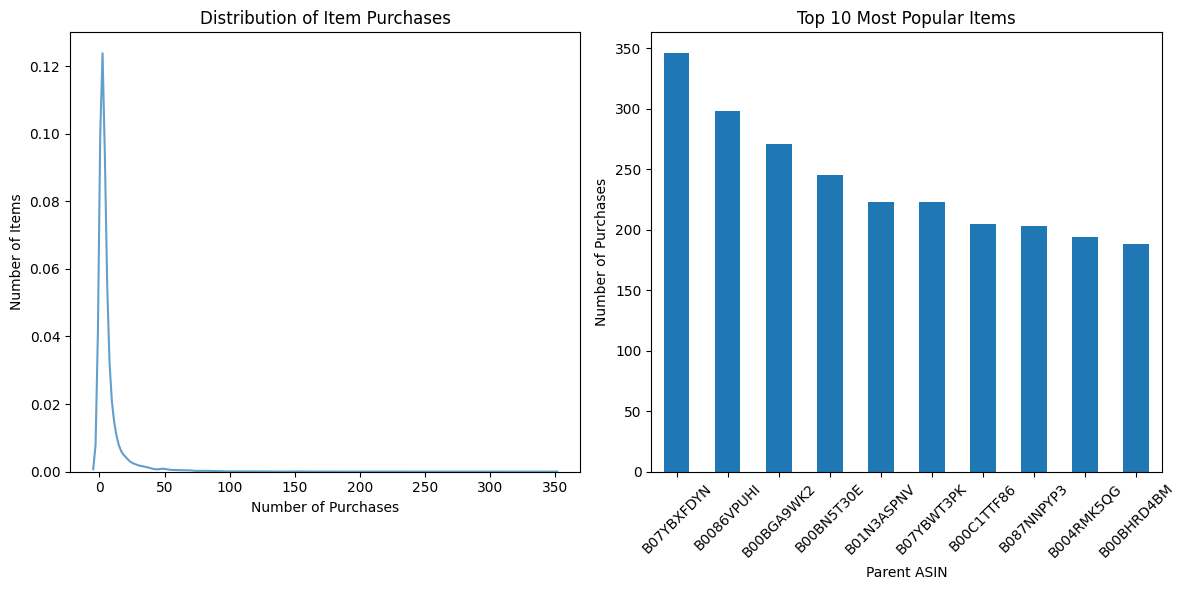


Item Purchase Distribution Statistics:
Mean purchases per item: 6.86
Median purchases per item: 3.00
Max purchases for an item: 346
Min purchases for an item: 1
Standard deviation: 13.96

User Statistics:
 Average purchases per user: 32.76
 Median purchases per user: 26.00
 Max purchases for a user: 473
 Min purchases for a user: 1
 Standard deviation: 22.80

Text Data Statistics:
Average tokens per item: 370.69
Max tokens for an item: 16119
Min tokens for an item: 21


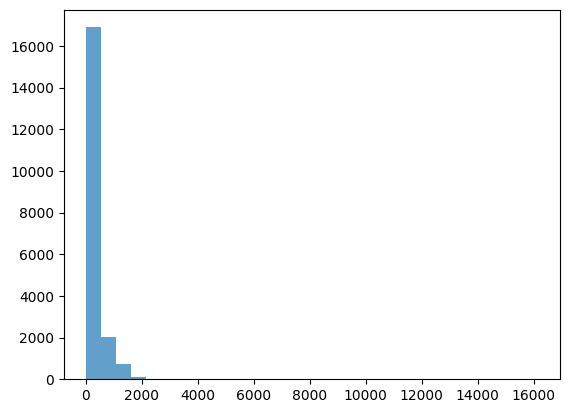

In [143]:
#Exploratory Data Analysis (EDA)
from matplotlib import pyplot as plt
import seaborn as sns
print(f"Number of unique items: {metadata_df.shape[0]}")
print(f"Number of unique users: {len(train_df['user_id'].unique())}")
print("Training set size: ", train_df.shape[0])
print("Training set unique items: ", train_df['parent_asin'].nunique())
print("Training set unique users: ", train_df['user_id'].nunique())
print("Test set size: ", test_df.shape[0])
print("Test set unique items: ", test_df['parent_asin'].nunique())
print("Test set unique users: ", test_df['user_id'].nunique())

# Distribution of item purchases (popularity)
item_purchase_counts = pd.concat([train_df['parent_asin'], test_df['parent_asin']]).value_counts()
top_items = item_purchase_counts.head(10)

# Plotting the distribution of item purchases
plt.figure(figsize=(12, 6))

# Plot histogram of item purchase counts
plt.subplot(1, 2, 1)
sns.kdeplot(item_purchase_counts, alpha=0.7)
plt.title('Distribution of Item Purchases')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Items')

# Plot top 10 most popular items
plt.subplot(1, 2, 2)
top_items.plot(kind='bar')
plt.title('Top 10 Most Popular Items')
plt.xlabel('Parent ASIN')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Basic statistics of purchase distribution
print("\nItem Purchase Distribution Statistics:")
print(f"Mean purchases per item: {item_purchase_counts.mean():.2f}")
print(f"Median purchases per item: {item_purchase_counts.median():.2f}")
print(f"Max purchases for an item: {item_purchase_counts.max()}")
print(f"Min purchases for an item: {item_purchase_counts.min()}")
print(f"Standard deviation: {item_purchase_counts.std():.2f}")

# Basic user statistics
print("\nUser Statistics:")
print(f" Average purchases per user: {train_df['user_id'].value_counts().mean():.2f}")
print(f" Median purchases per user: {train_df['user_id'].value_counts().median():.2f}")
print(f" Max purchases for a user: {train_df['user_id'].value_counts().max()}")
print(f" Min purchases for a user: {train_df['user_id'].value_counts().min()}")
print(f" Standard deviation: {train_df['user_id'].value_counts().std():.2f}")

# Check for text data statistics if available
if 'source_text' in metadata_df.columns:
    # Calculate token counts (approximation by word count)
    metadata_df['token_count'] = metadata_df['source_text'].str.split().str.len()
    
    print("\nText Data Statistics:")
    print(f"Average tokens per item: {metadata_df['token_count'].mean():.2f}")
    print(f"Max tokens for an item: {metadata_df['token_count'].max()}")
    print(f"Min tokens for an item: {metadata_df['token_count'].min()}")

plt.hist(metadata_df['token_count'], bins=30, alpha=0.7)
plt.show()

NOTED TO BE UPDATED, look at notebook amazon_beauty

## 2. Experiment

### 2.1 Hierarchical Topic Modeling
#### 2.1.1 all-MiniLM-L6-v2

In [146]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[0].replace('/', '_')


In [147]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
all_mini_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy.csv')
build_kg = Build_KG()
all_mini_triplet_df = build_kg.filter_entities(train_df, test_df, all_mini_triplet_df) 
train_df = build_kg.user_item_triples(train_df)
test_df = build_kg.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(all_mini_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


ASIN-like entities found in KG triples: 24343
ASIN-like entities with no intersection with unique_entities: 4537
Number of KG triples after removing ASIN-like entities with no intersection: 21549
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline
Combined KG has 157582 unique triples.
Found 25250 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 157582 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/kg_final.txt
Saved mapping files to /Users/

In [148]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--context_hops', N_CONTEXT_HOPS])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list
    
    """Graph statistics"""
    all_mini_density = nx.density(graph)
    print(f"Density of the graph: {all_mini_density}")
    all_mini_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {all_mini_avg_degree}")
    all_mini_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {all_mini_max_degree}")
    #all_mini_depth = nx.average_shortest_path_length(graph)
    #print(f"Average shortest path length of the graph: {all_mini_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,all_mini_predictions = test(model, user_dict, n_params)
        # save predictions
        all_mini_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        all_mini_metrics_table = PrettyTable()
        all_mini_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            all_mini_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        all_mini_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        all_mini_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        all_mini_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        all_mini_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        all_mini_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(all_mini_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 3990/3990 [00:00<00:00, 1724397.01it/s]



Begin to load knowledge graph triples ...


100%|##########| 315164/315164 [00:04<00:00, 72762.06it/s] 


End to build graph ... MultiDiGraph with 25250 nodes and 315164 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0008  |
|     NDCG@20      |  0.0023  |
|   Precision@20   |  0.0010  |
|   Hit_Ratio@20   |  0.0197  |
|    Recall@40     |  0.0015  |
|     NDCG@40      |  0.0033  |
|   Precision@40   |  0.0009  |
|   Hit_Ratio@40   |  0.0369  |
|    Recall@60     |  0.0018  |
|     NDCG@60      |  0.0037  |
|   Precision@60   |  0.0008  |
|   Hit_Ratio@60   |  0.0443  |
|    Recall@80     |  0.0024  |
|     NDCG@80      |  0.0044  |
|   Precision@80   |  0.0008  |
|   Hit_Ratio@80   |  0.0566  |
|    Recall@100    |  0.0028  |
|     NDCG@100     |  0.0048  |
|  Precision@100   |  0.0007  |
|  Hit_Ratio@100   |  0.0664  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.12   |
| Test Time (min)  |   0.70   |
|    Outer Loss    | 0.399433 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0006  |
|     NDCG@20      |  0.0018  |
|   Precision@20   |  0.0007  |
|   Hit_Ratio@20   |  0.0148  |
|    Recall@40     |  0.0011  |
|     NDCG@40      |  0.0025  |
|   Precision@40   |  0.0007  |
|   Hit_Ratio@40   |  0.0283  |
|    Recall@60     |  0.0018  |
|     NDCG@60      |  0.0033  |
|   Precision@60   |  0.0007  |
|   Hit_Ratio@60   |  0.0418  |
|    Recall@80     |  0.0023  |
|     NDCG@80      |  0.0039  |
|   Precision@80   |  0.0007  |
|   Hit_Ratio@80   |  0.0541  |
|    Recall@100    |  0.0025  |
|     NDCG@100     |  0.0041  |
|  Precision@100   |  0.0006  |
|  Hit_Ratio@100   |  0.0603  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.12   |
| Test Time (min)  |   0.71   |
|    Outer Loss    | 0.395760 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0006  |
|     NDCG@20      |  0.0015  |
|   Precision@20   |  0.0007  |
|   Hit_Ratio@20   |  0.0148  |
|    Recall@40     |  0.0011  |
|     NDCG@40      |  0.0022  |
|   Precision@40   |  0.0007  |
|   Hit_Ratio@40   |  0.0283  |
|    Recall@60     |  0.0014  |
|     NDCG@60      |  0.0025  |
|   Precision@60   |  0.0006  |
|   Hit_Ratio@60   |  0.0344  |
|    Recall@80     |  0.0017  |
|     NDCG@80      |  0.0029  |
|   Precision@80   |  0.0005  |
|   Hit_Ratio@80   |  0.0418  |
|    Recall@100    |  0.0021  |
|     NDCG@100     |  0.0033  |
|  Precision@100   |  0.0005  |
|  Hit_Ratio@100   |  0.0504  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.11   |
| Test Time (min)  |   0.72   |
|    Outer Loss    | 0.396444 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

#### 2.2.2 intfloat/multilingual-e5-large-instruct

build triplets from hierarchies for selected techniques

In [179]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
MODEL_TECHNIQUE = MODEL_TECHNIQUES[1].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [180]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
e5_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy.csv')

# filter entities
build_kg = Build_KG()
e5_triplet_df = build_kg.filter_entities(train_df, test_df, e5_triplet_df)

train_df = build_kg.user_item_triples(train_df)
test_df = build_kg.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(e5_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


ASIN-like entities found in KG triples: 18169
ASIN-like entities with no intersection with unique_entities: 0
Number of KG triples after removing ASIN-like entities with no intersection: 18206
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct
Combined KG has 154286 unique triples.
Found 23891 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 154286 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/d

set dataset configuration in parser

In [181]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--context_hops', N_CONTEXT_HOPS])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    """Graph statistics"""
    e5_density = nx.density(graph)
    print(f"Density of the graph: {e5_density}")
    e5_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {e5_avg_degree}")
    e5_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {e5_max_degree}")
    #e5_depth = nx.average_shortest_path_length(graph)
    #print(f"Average shortest path length of the graph: {e5_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, e5_predictions = test(model, user_dict, n_params)
        # save predictions
        e5_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        e5_metrics_table = PrettyTable()
        e5_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            e5_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        e5_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        e5_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        e5_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        e5_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        e5_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(e5_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 3990/3990 [00:00<00:00, 1172266.25it/s]



Begin to load knowledge graph triples ...


100%|##########| 308572/308572 [00:04<00:00, 62794.46it/s] 


End to build graph ... MultiDiGraph with 23891 nodes and 308572 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0004  |
|     NDCG@20      |  0.0010  |
|   Precision@20   |  0.0007  |
|   Hit_Ratio@20   |  0.0135  |
|    Recall@40     |  0.0008  |
|     NDCG@40      |  0.0017  |
|   Precision@40   |  0.0006  |
|   Hit_Ratio@40   |  0.0246  |
|    Recall@60     |  0.0010  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0006  |
|   Hit_Ratio@60   |  0.0344  |
|    Recall@80     |  0.0013  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0005  |
|   Hit_Ratio@80   |  0.0406  |
|    Recall@100    |  0.0014  |
|     NDCG@100     |  0.0028  |
|  Precision@100   |  0.0005  |
|  Hit_Ratio@100   |  0.0467  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.11   |
| Test Time (min)  |   0.64   |
|    Outer Loss    | 0.410106 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0004  |
|     NDCG@20      |  0.0010  |
|   Precision@20   |  0.0007  |
|   Hit_Ratio@20   |  0.0135  |
|    Recall@40     |  0.0008  |
|     NDCG@40      |  0.0017  |
|   Precision@40   |  0.0006  |
|   Hit_Ratio@40   |  0.0246  |
|    Recall@60     |  0.0011  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0006  |
|   Hit_Ratio@60   |  0.0344  |
|    Recall@80     |  0.0012  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0005  |
|   Hit_Ratio@80   |  0.0394  |
|    Recall@100    |  0.0014  |
|     NDCG@100     |  0.0027  |
|  Precision@100   |  0.0005  |
|  Hit_Ratio@100   |  0.0443  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.10   |
| Test Time (min)  |   0.64   |
|    Outer Loss    | 0.403328 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0004  |
|     NDCG@20      |  0.0010  |
|   Precision@20   |  0.0007  |
|   Hit_Ratio@20   |  0.0135  |
|    Recall@40     |  0.0007  |
|     NDCG@40      |  0.0017  |
|   Precision@40   |  0.0006  |
|   Hit_Ratio@40   |  0.0246  |
|    Recall@60     |  0.0011  |
|     NDCG@60      |  0.0023  |
|   Precision@60   |  0.0006  |
|   Hit_Ratio@60   |  0.0344  |
|    Recall@80     |  0.0012  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0005  |
|   Hit_Ratio@80   |  0.0394  |
|    Recall@100    |  0.0015  |
|     NDCG@100     |  0.0029  |
|  Precision@100   |  0.0005  |
|  Hit_Ratio@100   |  0.0480  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.11   |
| Test Time (min)  |   0.63   |
|    Outer Loss    | 0.407412 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

#### 2.2.3 Alibaba-NLP/gte-Qwen2-1.5B-instruct

In [152]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here

MODEL_TECHNIQUE = MODEL_TECHNIQUES[2].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [153]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
qwen2_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy.csv')

# filter entities
build_kg = Build_KG()
qwen2_triplet_df = build_kg.filter_entities(train_df, test_df, qwen2_triplet_df)
train_df = build_kg.user_item_triples(train_df)
test_df = build_kg.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(qwen2_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


ASIN-like entities found in KG triples: 18169
ASIN-like entities with no intersection with unique_entities: 0
Number of KG triples after removing ASIN-like entities with no intersection: 19428
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct
Combined KG has 155508 unique triples.
Found 24849 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 19428 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experimen

In [154]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--context_hops', N_CONTEXT_HOPS])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list
   
    """Graph statistics"""
    qwen2_density = nx.density(graph)
    print(f"Density of the graph: {qwen2_density}")
    qwen2_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {qwen2_avg_degree}")
    #qwen2_max_degree = max(dict(nx.degree(graph)).values())
    #print(f"Max degree of the graph: {qwen2_max_degree}")
    
    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, qwen2_predictions = test(model, user_dict, n_params)
        # save predictions
        qwen2_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        qwen2_metrics_table = PrettyTable()
        qwen2_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            qwen2_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        qwen2_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        qwen2_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        qwen2_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        qwen2_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        qwen2_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(qwen2_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 3990/3990 [00:00<00:00, 1376256.00it/s]



Begin to load knowledge graph triples ...


100%|##########| 38778/38778 [00:00<00:00, 474000.75it/s]


End to build graph ... MultiDiGraph with 19165 nodes and 38778 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0004  |
|     NDCG@20      |  0.0008  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0086  |
|    Recall@40     |  0.0006  |
|     NDCG@40      |  0.0011  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0148  |
|    Recall@60     |  0.0009  |
|     NDCG@60      |  0.0015  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0221  |
|    Recall@80     |  0.0013  |
|     NDCG@80      |  0.0020  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0332  |
|    Recall@100    |  0.0014  |
|     NDCG@100     |  0.0021  |
|  Precision@100   |  0.0004  |
|  Hit_Ratio@100   |  0.0369  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.02   |
| Test Time (min)  |   0.65   |
|    Outer Loss    | 0.559821 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0003  |
|     NDCG@20      |  0.0007  |
|   Precision@20   |  0.0004  |
|   Hit_Ratio@20   |  0.0074  |
|    Recall@40     |  0.0006  |
|     NDCG@40      |  0.0012  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0160  |
|    Recall@60     |  0.0009  |
|     NDCG@60      |  0.0015  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0221  |
|    Recall@80     |  0.0010  |
|     NDCG@80      |  0.0018  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0271  |
|    Recall@100    |  0.0013  |
|     NDCG@100     |  0.0020  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0332  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.02   |
| Test Time (min)  |   0.67   |
|    Outer Loss    | 0.545361 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0003  |
|     NDCG@20      |  0.0010  |
|   Precision@20   |  0.0004  |
|   Hit_Ratio@20   |  0.0074  |
|    Recall@40     |  0.0007  |
|     NDCG@40      |  0.0015  |
|   Precision@40   |  0.0005  |
|   Hit_Ratio@40   |  0.0172  |
|    Recall@60     |  0.0009  |
|     NDCG@60      |  0.0018  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0221  |
|    Recall@80     |  0.0011  |
|     NDCG@80      |  0.0021  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0283  |
|    Recall@100    |  0.0012  |
|     NDCG@100     |  0.0022  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0320  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.02   |
| Test Time (min)  |   0.66   |
|    Outer Loss    | 0.550535 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

In [155]:
e5_qwen2_lev_ratio = levenshtein_distance(e5_triplet_df, qwen2_triplet_df)
e5_mini_lev_ratio = levenshtein_distance(e5_triplet_df, all_mini_triplet_df)
qwen2_mini_lev_ratio = levenshtein_distance(qwen2_triplet_df, all_mini_triplet_df)

print(f"Levenshtein distance between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: {e5_qwen2_lev_ratio}") 
print(f"Levenshtein distance between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: {e5_mini_lev_ratio}")    
print(f"Levenshtein distance between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: {qwen2_mini_lev_ratio}")


print(f"Cosine similarity between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: {calc_cosine_similarity_fixed(e5_triplet_df, qwen2_triplet_df, embedding_model)}")
print(f"Cosine similarity between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: {calc_cosine_similarity_fixed(e5_triplet_df, all_mini_triplet_df, embedding_model)}")
print(f"Cosine similarity between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: {calc_cosine_similarity_fixed(qwen2_triplet_df, all_mini_triplet_df, embedding_model)}")


Levenshtein distance between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: 0.14504460071431108
Levenshtein distance between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: 0.14234029177766291
Levenshtein distance between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: 0.3416658262438572
Cosine similarity between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: 0.23463204503059387
Cosine similarity between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: 0.21720252931118011
Cosine similarity between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: 0.3553856611251831


To measure similarity between the different constructed topics of the different embedding models cosine similarity seems to be the better similarity measure. As displayed in the above the embedding models in BERTTopic generate lexical very different topics with the same meaning. The levenstein similarity for all scenarios is lower compared to the cosine similarity. Levenstein similarity is between 0.13 and 0.34 meanwhile the cosine similarity is between 0.22 and 0.36. 

![BERTopic Algorithm](https://maartengr.github.io/BERTopic/algorithm/default.svg)


Looking at the BERTTopic algorithm gives an explanation for this. 
To create topic represantation BERTTopic uses after a clustering a Bag-of-Words (CountVectorizer). It counts how often words appears in a given cluster. Further it uses a TF-IDF transformation to weight the words to focus on specific words in a cluster. In this case the created cluster seems to be similar, but not the same. Therefore curtent words may apear less in the cluster and wont be used in the TF-IDF transformation. On the other hand the intersection of the topics provide semantically similar topics which can be seen in the cosine similarity.

### 2.2 Hearst-Patterns Named-Entity-Recognition (Rebel-large)

In [176]:
MODEL_TECHNIQUE = MODEL_TECHNIQUES[4].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [177]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
rebel_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy.csv')
len_before = len(rebel_triplet_df)
# filter out relation where one column is empty
rebel_triplet_df = rebel_triplet_df[rebel_triplet_df['head'].notna() & rebel_triplet_df['tail'].notna()]
len_after = len(rebel_triplet_df)
filtered_out = len_before - len_after
print(f"Filtered out {filtered_out} relations where one column is empty")

# filter entities
build_kg = Build_KG()
rebel_triplet_df = build_kg.filter_entities(train_df, test_df, rebel_triplet_df)
train_df = build_kg.user_item_triples(train_df)
test_df = build_kg.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(rebel_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Filtered out 32127 relations where one column is empty
ASIN-like entities found in KG triples: 14392
ASIN-like entities with no intersection with unique_entities: 2904
Number of KG triples after removing ASIN-like entities with no intersection: 37247
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner
Combined KG has 173327 unique triples.
Found 39227 unique entities.
Found 115 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 173327 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/kg_fin

In [178]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--context_hops', N_CONTEXT_HOPS])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    """Graph statistics"""
    rebel_density = nx.density(graph)
    print(f"Density of the graph: {rebel_density}")
    rebel_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {rebel_avg_degree}")
    rebel_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {rebel_max_degree}")
    #rebel_depth = nx.average_shortest_path_length(graph)
    #print(f"Average shortest path length of the graph: {rebel_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, rebel_predictions = test(model, user_dict, n_params)
        # save predictions
        rebel_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        rebel_metrics_table = PrettyTable()
        rebel_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            rebel_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        rebel_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        rebel_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        rebel_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        rebel_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        rebel_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(rebel_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 3990/3990 [00:00<00:00, 1525827.22it/s]



Begin to load knowledge graph triples ...


100%|##########| 346654/346654 [00:03<00:00, 86770.14it/s] 


End to build graph ... MultiDiGraph with 39227 nodes and 346654 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0003  |
|     NDCG@20      |  0.0011  |
|   Precision@20   |  0.0006  |
|   Hit_Ratio@20   |  0.0111  |
|    Recall@40     |  0.0005  |
|     NDCG@40      |  0.0015  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0172  |
|    Recall@60     |  0.0011  |
|     NDCG@60      |  0.0024  |
|   Precision@60   |  0.0006  |
|   Hit_Ratio@60   |  0.0369  |
|    Recall@80     |  0.0015  |
|     NDCG@80      |  0.0030  |
|   Precision@80   |  0.0006  |
|   Hit_Ratio@80   |  0.0492  |
|    Recall@100    |  0.0017  |
|     NDCG@100     |  0.0032  |
|  Precision@100   |  0.0006  |
|  Hit_Ratio@100   |  0.0541  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.14   |
| Test Time (min)  |   1.04   |
|    Outer Loss    | 0.394287 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0000  |
|     NDCG@20      |  0.0000  |
|   Precision@20   |  0.0000  |
|   Hit_Ratio@20   |  0.0000  |
|    Recall@40     |  0.0000  |
|     NDCG@40      |  0.0000  |
|   Precision@40   |  0.0000  |
|   Hit_Ratio@40   |  0.0000  |
|    Recall@60     |  0.0000  |
|     NDCG@60      |  0.0000  |
|   Precision@60   |  0.0000  |
|   Hit_Ratio@60   |  0.0000  |
|    Recall@80     |  0.0000  |
|     NDCG@80      |  0.0000  |
|   Precision@80   |  0.0000  |
|   Hit_Ratio@80   |  0.0000  |
|    Recall@100    |  0.0000  |
|     NDCG@100     |  0.0000  |
|  Precision@100   |  0.0000  |
|  Hit_Ratio@100   |  0.0000  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.17   |
| Test Time (min)  |   0.83   |
|    Outer Loss    | 0.382722 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment varia

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0000  |
|     NDCG@20      |  0.0000  |
|   Precision@20   |  0.0000  |
|   Hit_Ratio@20   |  0.0000  |
|    Recall@40     |  0.0000  |
|     NDCG@40      |  0.0000  |
|   Precision@40   |  0.0000  |
|   Hit_Ratio@40   |  0.0000  |
|    Recall@60     |  0.0000  |
|     NDCG@60      |  0.0000  |
|   Precision@60   |  0.0000  |
|   Hit_Ratio@60   |  0.0000  |
|    Recall@80     |  0.0000  |
|     NDCG@80      |  0.0000  |
|   Precision@80   |  0.0000  |
|   Hit_Ratio@80   |  0.0000  |
|    Recall@100    |  0.0000  |
|     NDCG@100     |  0.0000  |
|  Precision@100   |  0.0000  |
|  Hit_Ratio@100   |  0.0000  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.20   |
| Test Time (min)  |   0.81   |
|    Outer Loss    |   nan    |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

### 2.3 LLM-Col-Hierarchy-Tax (Gemma 3)


In [51]:
DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[3].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [52]:
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-triples.csv')
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

build_kg = Build_KG()
gemma_triplet_df = build_kg.filter_entities(train_df, test_df, gemma_triplet_df)

train_df = build_kg.user_item_triples(train_df)
test_df = build_kg.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


ASIN-like entities found in KG triples: 2650
ASIN-like entities with no intersection with unique_entities: 0
Number of KG triples after removing ASIN-like entities with no intersection: 24103
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3
Combined KG has 160183 unique triples.
Found 23906 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 160183 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/kg_final.txt
Saved mapping files to /Users/U725801/Docu

In [53]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--context_hops', "9"])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    gemma_density = nx.density(graph)
    print(f"Density of the graph: {gemma_density}")
    gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {gemma_avg_degree}")
    gemma_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {gemma_max_degree}")
    #gemma_avg_shortest_path_length = nx.average_shortest_path_length(graph)
    #print(f"Average shortest path length of the graph: {gemma_avg_shortest_path_length}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    #print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, gemma_predictions = test(model, user_dict, n_params)
        # save predictions
        gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        gemma_metrics_table = PrettyTable()
        gemma_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(gemma_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 3990/3990 [00:00<00:00, 1557928.97it/s]



Begin to load knowledge graph triples ...


100%|##########| 320366/320366 [00:03<00:00, 96991.26it/s] 


End to build graph ... MultiDiGraph with 23906 nodes and 320366 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 7/7 [00:00<00:00, 74.62it/s]


Density of the graph: 0.0005605969822577597
Average degree of the graph: 26.802141721743496
Max degree of the graph: 3738
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23868
start training ...

Epoch 1/5
Number of iterations expected: 1
Processing 3990 samples in batches of 2048

First batch statistics:
Users shape: torch.Size([2048])
Positive items shape: torch.Size([2048])
Negative items shape: torch.Size([2048])

Iteration 0 losses:
rec_loss: 0.361976
inv_mean: 3.311235
inv_var: 0.000708
outer_loss: 0.395095

Gradient norms:
all_embed: 0.903515
latent_emb: 0.000064
gcn.weight: 0.138025
gcn.disen_weight_att: 0.000523
gcn.invariant_generator.kg_W_r: 0.000001
augmenter.edge_mlp_list.0.0.weight: 0.000023
augmenter.edge_mlp_list.0.0.bias: 0.000016
augmenter.edge_mlp_list.0.2.weight: 0.000008
augmenter.edge_mlp_list.0.2.bias: 0.000012
augmenter.edge_mlp_list.1.0.weight: 0.000031
augmenter.edge_mlp_list.1.0

## 3. Results

Comparison of Different Taxonomy Methods:
+--------------------------------------------+-----------+--------------+---------+--------------+
|                   Method                   | Recall@20 | Precision@20 | NDCG@20 | Hit_Ratio@20 |
+--------------------------------------------+-----------+--------------+---------+--------------+
|                  Baseline                  |   0.0006  |    0.0007    |  0.0016 |    0.0148    |
|    Hierarchical-Topic-e5-large-instruct    |   0.0004  |    0.0007    |  0.0010 |    0.0135    |
|      Hierarchical-Topic-MiniLM-L6-v2       |   0.0006  |    0.0007    |  0.0015 |    0.0148    |
| Hierarchical-Topic-gte-Qwen2-1.5B-instruct |   0.0003  |    0.0004    |  0.0010 |    0.0074    |
|      Hearst-Patterns NER-Rebel-large       |   0.0000  |    0.0000    |  0.0000 |    0.0000    |
|           LLM-Col-Hierarchy-Tax            |   0.0007  |    0.0011    |  0.0026 |    0.0209    |
|      Delta LLM-Col-Hierarchy-Tax (%)       |  16.6667  |   57.142

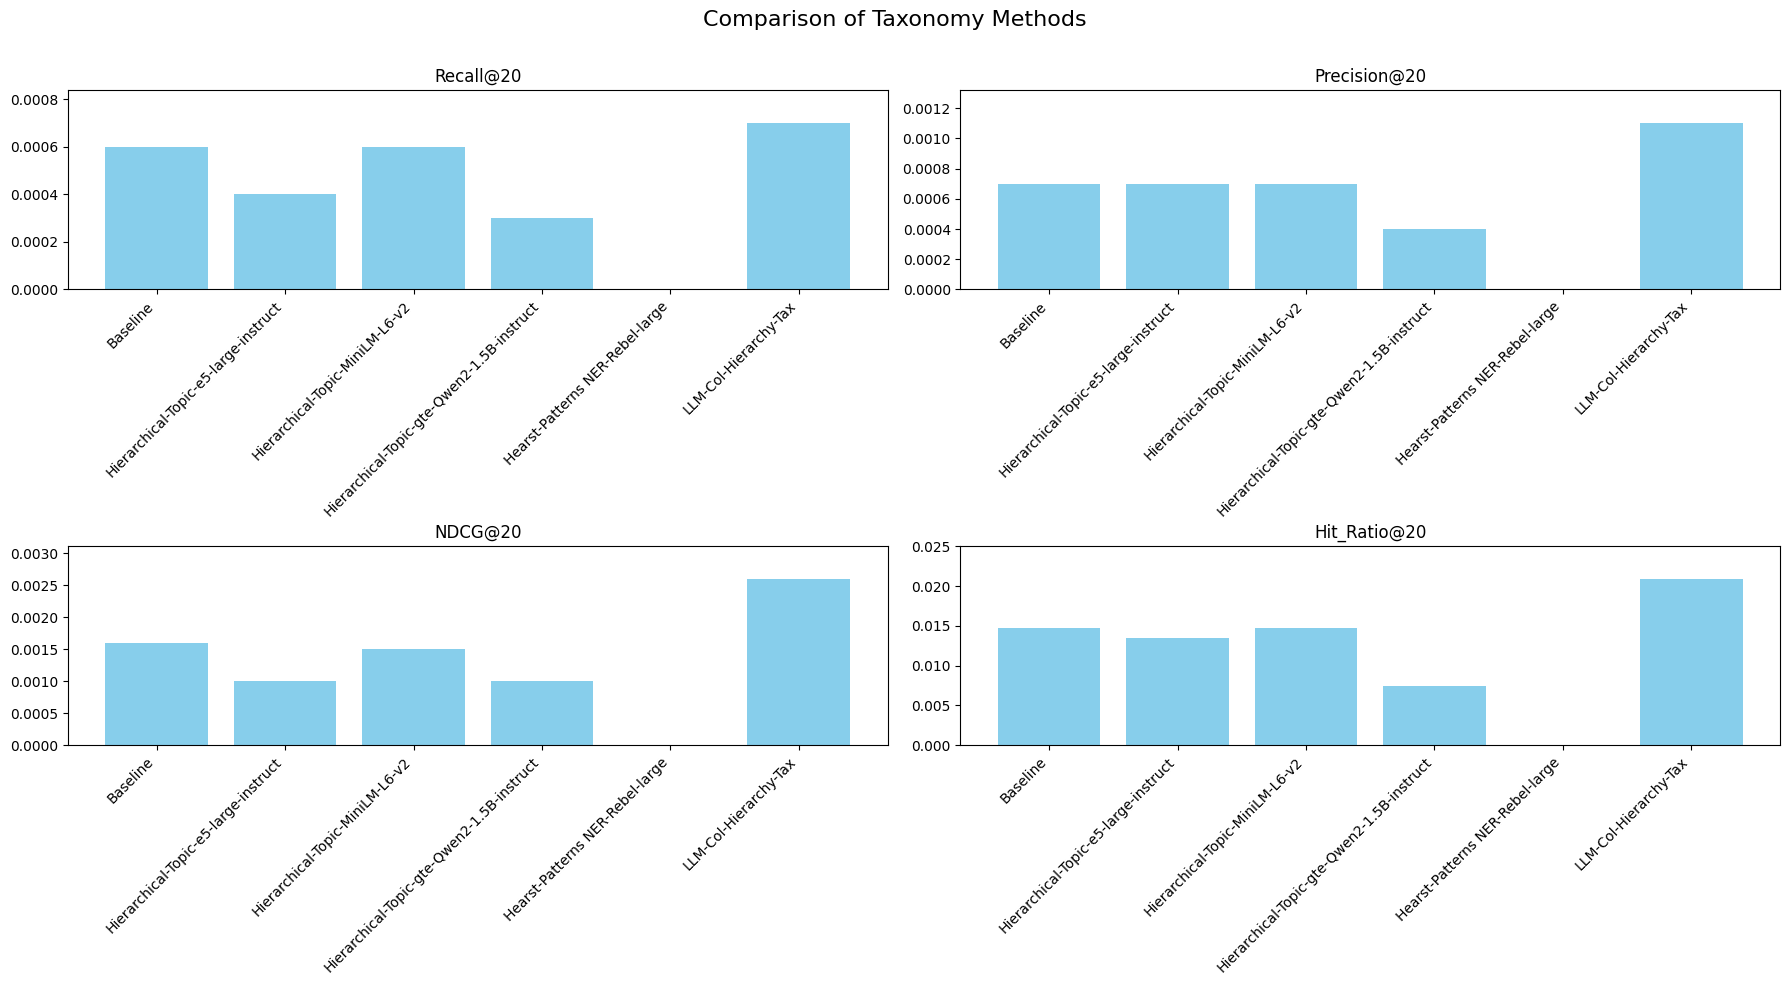

In [182]:

# Use the safe extraction function instead
baseline_key_metrics = safe_extract_metrics(baseline_metrics_table, "Baseline")
e5_key_metrics = safe_extract_metrics(e5_metrics_table, "Hierarchical-Topic-e5-large-instruct")
all_mini_key_metrics = safe_extract_metrics(all_mini_metrics_table, "Hierarchical-Topic-MiniLM-L6-v2")
qwen2_key_metrics = safe_extract_metrics(qwen2_metrics_table, "Hierarchical-Topic-gte-Qwen2-1.5B-instruct")
rebel_key_metrics = safe_extract_metrics(rebel_metrics_table, "Hearst-Patterns NER-Rebel-large")
gemma_key_metrics = safe_extract_metrics(gemma_metrics_table, "LLM-Col-Hierarchy-Tax")

results_list = [baseline_key_metrics, e5_key_metrics, all_mini_key_metrics, qwen2_key_metrics, rebel_key_metrics, gemma_key_metrics]


# Find the best and second best values for each metric
metrics_to_compare = ['Recall@20', 'Precision@20', 'NDCG@20', 'Hit_Ratio@20']
best_values = {}
second_best_values = {}

for metric in metrics_to_compare:
    # Extract values for this metric from all methods
    values = [result[metric] for result in results_list]
    # Sort values in descending order
    sorted_values = sorted(values, reverse=True)
    
    # Store best and second best values
    if len(sorted_values) >= 1:
        best_values[metric] = sorted_values[0]
    if len(sorted_values) >= 2:
        second_best_values[metric] = sorted_values[1]

# Calculate delta for Gemma3 compared to baseline
gemma_deltas = {}

for metric in metrics_to_compare:
    gemma_value = gemma_key_metrics[metric]
    
    # Delta to best
    if metric in best_values:
        if gemma_value == best_values[metric]:
            # If Gemma is the best, compare to second best
            if metric in second_best_values:
                delta = gemma_value - second_best_values[metric]
                gemma_deltas[f"{metric}"] = delta
                gemma_deltas[f"{metric}"] = (delta / second_best_values[metric]) * 100 if second_best_values[metric] != 0 else float('inf')
        else:
            # If Gemma is not the best, compare to best
            delta = gemma_value - best_values[metric]
            gemma_deltas[f"{metric}"] = (delta / best_values[metric]) * 100 if best_values[metric] != 0 else float('inf')
# add to results_list
results_list[5]['LLM-Col-Hierarchy-Tax_Delta'] = gemma_deltas

# Create a pretty table to display the results
from prettytable import PrettyTable

acc_comparison_table = PrettyTable()
acc_comparison_table.field_names = ["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"]

# Add rows to the table
for result in results_list:
    acc_comparison_table.add_row([
        result['Method'],
        f"{result['Recall@20']:.4f}",
        f"{result['Precision@20']:.4f}",
        f"{result['NDCG@20']:.4f}",
        f"{result['Hit_Ratio@20']:.4f}",
    ])

# add gemma3_delta to the table
acc_comparison_table.add_row([
    "Delta LLM-Col-Hierarchy-Tax (%)",
    f"{gemma_deltas['Recall@20']:.4f}",
    f"{gemma_deltas['Precision@20']:.4f}",
    f"{gemma_deltas['NDCG@20']:.4f}",
    f"{gemma_deltas['Hit_Ratio@20']:.4f}",
])

# Display the comparison table
print("Comparison of Different Taxonomy Methods:")
print(acc_comparison_table)

# Optionally, create a bar chart to visualize the comparison
import matplotlib.pyplot as plt
import numpy as np

# Check if we have results to plot
if results_list:
    # Extract method names and metrics
    method_names = [result['Method'] for result in results_list]
    recall_values = [result['Recall@20'] for result in results_list]
    precision_values = [result['Precision@20'] for result in results_list]
    ndcg_values = [result['NDCG@20'] for result in results_list]
    hr_values = [result['Hit_Ratio@20'] for result in results_list]
    
    # Set up the figure
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle('Comparison of Taxonomy Methods', fontsize=16)
    
    # Create bar charts for each metric
    metrics = [recall_values, precision_values, ndcg_values, hr_values]
    metric_names = ['Recall@20', 'Precision@20', 'NDCG@20', 'Hit_Ratio@20']
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        row, col = i // 2, i % 2
        axs[row, col].bar(method_names, metric, color='skyblue')
        axs[row, col].set_title(name)
        axs[row, col].set_ylim(0, max(metric) * 1.2)  # Add some space above the bars
        axs[row, col].set_xticklabels(method_names, rotation=45, ha='right')
    
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
else:
    print("No results available to plot.")


In [183]:
df_kg_stats = pd.DataFrame(columns=['Method', 'Density', 'Average Degree', 'Max Degree', 'Average Shortest Path Length'])
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Baseline"], 
    "Density": [baseline_density], 
    "Average Degree": [baseline_avg_degree], 
    "Max Degree": [baseline_max_degree], 
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-MiniLM-L6-v2"], 
    "Density": [all_mini_density], 
    "Average Degree": [all_mini_avg_degree], 
    "Max Degree": [all_mini_max_degree], 
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-e5-large-instruct"], 
    "Density": [e5_density], 
    "Average Degree": [e5_avg_degree], 
    "Max Degree": [e5_max_degree], 
})], ignore_index=True)
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-gte-Qwen2-1.5B-instruct"], 
    "Density": [qwen2_density], 
    "Average Degree": [qwen2_avg_degree], 
    "Average Shortest Path Length": [0]
})], ignore_index=True)
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hearst-Patterns NER-Rebel-large"], 
    "Density": [rebel_density], 
    "Average Degree": [rebel_avg_degree], 
    "Max Degree": [rebel_max_degree], 
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    'Method': ['LLM-Col-Hierarchy-Tax'], 
    'Density': [gemma_density], 
    'Average Degree': [gemma_avg_degree], 
    'Max Degree': [gemma_max_degree], 
})], ignore_index=True)


# transform acc_comparison_table to df
acc_comparison_df = pd.DataFrame(acc_comparison_table.rows, columns=["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"])
acc_comparison_df = acc_comparison_df[acc_comparison_df['Method'] != 'Delta LLM-Col-Hierarchy-Tax (%)']

# Create DataFrame excluding the delta row
acc_comparison_df = pd.DataFrame(acc_comparison_df, columns=["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"])


In [184]:
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET)
# Exerpiemt path prior directory
acc_comparison_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-copy_acc_comparison_df.csv", index=False)

In [55]:
# relationship between density and ncdg@20
# corr between density and ncdg@20
density_ndcg_corr = df_kg_stats['Density'].corr(acc_comparison_df['Hit_Ratio@20'])
print(f"Correlation between Density and Hit_Ratio@20: {density_ndcg_corr:.4f}")
density_rec_corr = df_kg_stats['Density'].corr(acc_comparison_df['Precision@20'])
print(f"Correlation between Density and Precision@20: {density_rec_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Density and Precision@20 / HR@20')
axs[0].scatter(df_kg_stats['Density'], acc_comparison_df['Hit_Ratio@20'])
axs[0].set_xlabel('Density')
axs[0].set_ylabel('Hit_Ratio@20')

axs[1].scatter(df_kg_stats['Density'], acc_comparison_df['Precision@20'])
axs[1].set_xlabel('Density')
axs[1].set_ylabel('Precision@20')
plt.show()

NameError: name 'df_kg_stats' is not defined

Correlation between Max Degree and Recall@20: 0.2202
Correlation between Max Degree and NCDG@20: 0.0592


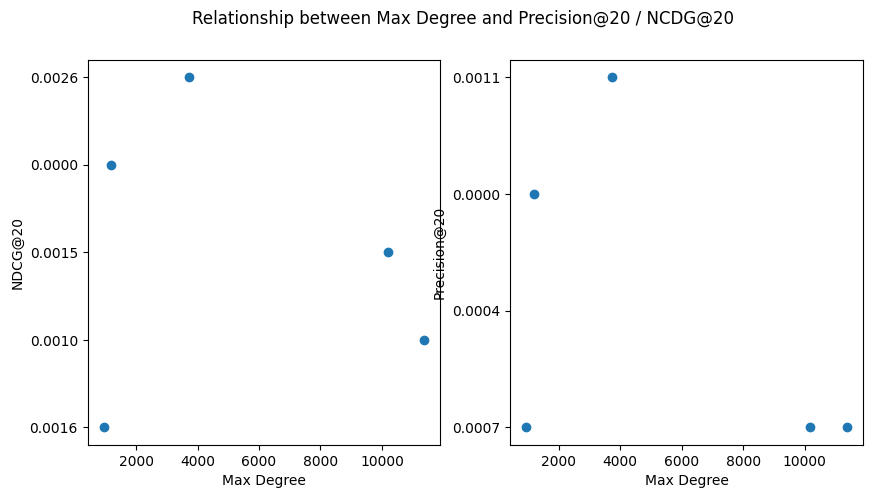

In [186]:
# relationship between max degree and recall@20
max_rec_corr = df_kg_stats['Max Degree'].corr(acc_comparison_df['Hit_Ratio@20'])
print(f"Correlation between Max Degree and Recall@20: {max_rec_corr:.4f}")
max_ndcg_corr = df_kg_stats['Max Degree'].corr(acc_comparison_df['Precision@20'])
print(f"Correlation between Max Degree and Precision@20: {max_ndcg_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Max Degree and Precision@20 / NCDG@20')
axs[0].scatter(df_kg_stats['Max Degree'], acc_comparison_df['NDCG@20'])
axs[0].set_xlabel('Max Degree')
axs[0].set_ylabel('NDCG@20')

axs[1].scatter(df_kg_stats['Max Degree'], acc_comparison_df['Precision@20'])
axs[1].set_xlabel('Max Degree')
axs[1].set_ylabel('Precision@20')
plt.show()


In [187]:
# avg degree and ncdg@20
avg_degree_ndcg_corr = df_kg_stats['Average Degree'].corr(acc_comparison_df['Precision@20'])
print(f"Correlation between Average Degree and Precision@20: {avg_degree_ndcg_corr:.4f}")
avg_degree_hr_corr = df_kg_stats['Average Degree'].corr(acc_comparison_df['Hit_Ratio@20'])
print(f"Correlation between Average Degree and Hit_Ratio@20: {avg_degree_hr_corr:.4f}")


Correlation between Average Degree and Precision@20: 0.5877
Correlation between Average Degree and Hit_Ratio@20: 0.6201


In [44]:
import mlflow
import os
import pandas as pd # Keep import for pd used below
# load all n_hops dfs and add n_hops to the df and merge them into one df
N_HOPS_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET)
all_n_hops_df = pd.DataFrame()
for n_hops in [3,5,7,9]:
    n_hops_df = pd.read_csv(f"{N_HOPS_PATH}/{n_hops}_acc_comparison_df.csv")
    n_hops_df['n_hops'] = n_hops
    all_n_hops_df = pd.concat([all_n_hops_df, n_hops_df], ignore_index=True)


# Set MLflow experiment
EXPERIMENT_NAME_MLFLOW = "#1 Comparison Technique" # Keep experiment name
mlflow.set_experiment(EXPERIMENT_NAME_MLFLOW)

# Start a new run for logging the analysis results - Updated run name
with mlflow.start_run(run_name=DATASET): # Updated run_name to DATASET

    # Log the dataset name as a tag
    mlflow.set_tag("dataset", DATASET)
    print(f"Logged dataset tag: {DATASET}")

    # Log correlation metrics calculated in previous cells
    try:
        mlflow.log_metric("corr_density_recall20", density_rec_corr)
        mlflow.log_metric("corr_density_ndcg20", density_ndcg_corr)
        mlflow.log_metric("corr_max_degree_recall20", max_rec_corr)
        mlflow.log_metric("corr_max_degree_ndcg20", max_ndcg_corr)
        print("Logged correlation metrics to MLflow.")
    except NameError as e:
        print(f"Could not log correlation metrics, variable not found: {e}")
    except Exception as e:
        print(f"An error occurred while logging correlation metrics: {e}")

# Log all KG statistics metrics per method
    try:
        # Ensure the index is the method name for proper logging keys if needed
        # If 'Method' is already the index, this step is not strictly necessary
        if 'Method' in df_kg_stats.columns:
            df_kg_stats_log = df_kg_stats.set_index('Method')
        else:
            df_kg_stats_log = df_kg_stats # Assume index is already 'Method'

        for method, stats in df_kg_stats_log.iterrows():
            # Sanitize method name for MLflow metric key
            safe_method_name = "".join(c if c.isalnum() else "_" for c in str(method))
            metrics_to_log = {f"kg_stat_{safe_method_name}_{stat_name.replace(' ', '_')}": value
                              for stat_name, value in stats.items() if pd.notna(value)}
            mlflow.log_metrics(metrics_to_log)
        print("Logged KG statistics per method to MLflow.")
    except NameError as e:
        print(f"Could not log KG stats, variable 'df_kg_stats' not found: {e}")
    except Exception as e:
        print(f"An error occurred while logging KG stats: {e}")

# Log all performance metrics from all_n_hops_df in tabular format
    try:
        # Check if all_n_hops_df exists
        if 'all_n_hops_df' not in locals() and 'all_n_hops_df' not in globals():
             raise NameError("name 'all_n_hops_df' is not defined")

        # Log the performance metrics DataFrame as a table artifact (JSON format)
        # This table includes 'Method' (model technique name) and 'n_hops'.
        # Note: 'batch_size' and 'test_batch_size' were requested but are not available
        # in the 'all_n_hops_df' DataFrame in this context.
        # If these columns were added to the DataFrame earlier (e.g., during its creation in cell 62),
        # they would be automatically included in the logged table.
        mlflow.log_table(data=all_n_hops_df, artifact_file="performance_metrics.json")

        print("Logged performance metrics table (all_n_hops_df) to MLflow artifact 'performance_metrics.json'.")
    except NameError as e:
        print(f"Could not log performance metrics table, variable 'all_n_hops_df' not found: {e}")
    except Exception as e:
        print(f"An error occurred while logging performance metrics table: {e}")

    # Removed artifact logging section as per instructions focusing on metrics

    print(f"MLflow Run ID for analysis: {mlflow.active_run().info.run_id}")


Logged dataset tag: amazon-Video_Games
Could not log correlation metrics, variable not found: name 'density_rec_corr' is not defined
Could not log KG stats, variable 'df_kg_stats' not found: name 'df_kg_stats' is not defined
Logged performance metrics table (all_n_hops_df) to MLflow artifact 'performance_metrics.json'.
MLflow Run ID for analysis: b80e2471f96848c6b986f44d18f062a5


In [169]:
!mlflow ui

## 3. Interpretation and Discussion